# LSApp User-Day Clustering Analysis
Run PCA and compare multiple clustering methods (KMeans, GMM, Agglomerative) to discover behavioral user patterns.

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

pd.set_option('display.max_columns', 50)

In [34]:
# Setup paths.
project_root = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
features_file = project_root / 'data' / 'features' / 'lsapp_user_day_clustering_features.tsv'
results_dir = project_root / 'data' / 'clustering_results'
results_dir.mkdir(parents=True, exist_ok=True)

if not features_file.exists():
    raise FileNotFoundError(f'Features file not found: {features_file}')

print(f'Features file: {features_file}')
print(f'Results directory: {results_dir}')

Features file: d:\Git\context-aware-user-recommendation\data\features\lsapp_user_day_clustering_features.tsv
Results directory: d:\Git\context-aware-user-recommendation\data\clustering_results


## 1. Load and Preprocess Features

In [35]:
# Load features.
df = pd.read_csv(features_file, sep='\t')
print(f'Loaded shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Loaded shape: (2907, 42)
Columns: ['user_id', 'date', 'num_unique_apps', 'num_unique_categories', 'total_duration', 'avg_session_duration', 'day_of_week_num', 'is_weekend', 'app_store_ratio', 'browser_search_ratio', 'communication_ratio', 'communication_email_ratio', 'communication_social_ratio', 'entertainment_ratio', 'finance_ratio', 'games_ratio', 'maps_navigation_ratio', 'music_audio_ratio', 'news_ratio', 'photo_video_ratio', 'productivity_ratio', 'rewards_ratio', 'shopping_ratio', 'social_ratio', 'social_forum_ratio', 'social_news_ratio', 'social_visual_ratio', 'system_ratio', 'utility_ratio', 'video_streaming_ratio', 'morning_duration_ratio', 'afternoon_duration_ratio', 'evening_duration_ratio', 'late_night_duration_ratio', 'health_ratio', 'survey_ratio', 'app_entropy', 'category_entropy', 'app_switch_count', 'category_switch_count', 'switch_rate_per_interaction', 'avg_gap_between_interactions_seconds_log1p']


In [36]:
# Select numeric features for clustering (exclude metadata).
exclude_cols = {'user_id', 'date', 'day_of_week', 'day_of_week_num'} if 'day_of_week_num' in df.columns else {'user_id', 'date', 'day_of_week'}
numeric_cols = [c for c in df.columns if df[c].dtype in [np.float64, np.float32, np.int64, np.int32] and c not in exclude_cols]

X = df[numeric_cols].copy()
X = X.fillna(0)  # Fill missing values with 0.

print(f'Feature matrix shape: {X.shape}')
print(f'Selected {len(numeric_cols)} numeric features')

Feature matrix shape: (2907, 39)
Selected 39 numeric features


In [37]:
# Standardize features using StandardScaler.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

# Save scaler.
scaler_out = results_dir / 'scaler.pkl'
joblib.dump(scaler, scaler_out)

print(f'Standardized shape: {X_scaled.shape}')
print(f'Saved scaler: {scaler_out}')

Standardized shape: (2907, 39)
Saved scaler: d:\Git\context-aware-user-recommendation\data\clustering_results\scaler.pkl


## 2. PCA Analysis and Visualization

In [38]:
# Fit PCA with all components.
pca_full = PCA()
pca_full.fit(X_scaled)

# Determine k for ~95% explained variance.
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
k_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f'Components for 95% variance: {k_95}')
print(f'Cumulative variance (first 10): {cumsum_var[:10]}')

Components for 95% variance: 30
Cumulative variance (first 10): [0.13916448 0.19182873 0.2353852  0.27700705 0.31546836 0.35164603
 0.38245458 0.41271549 0.44254655 0.47153802]


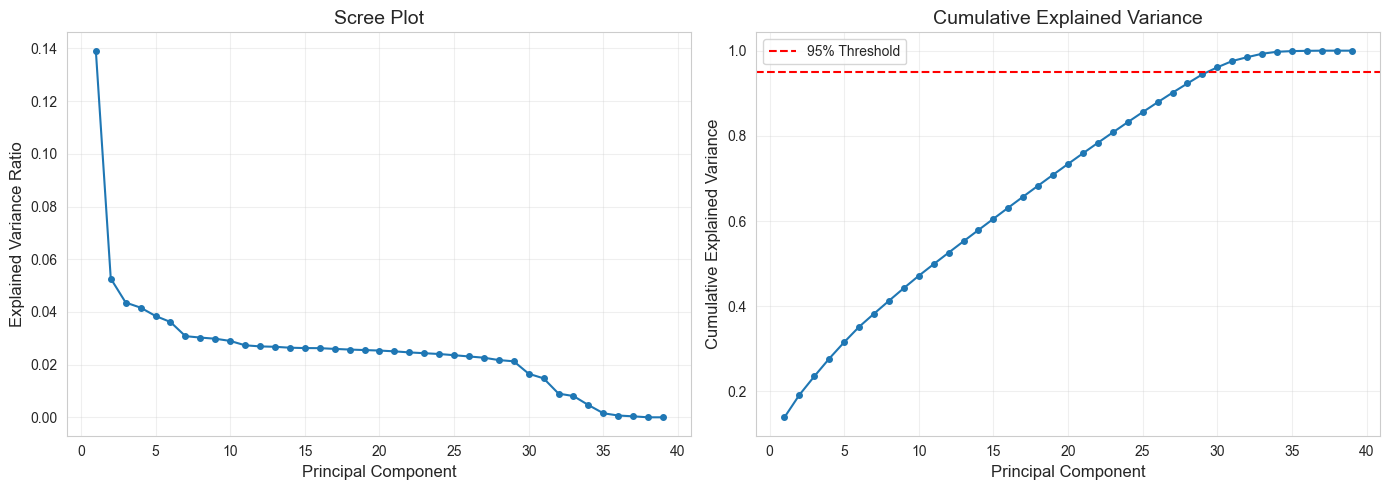

Saved: pca_scree_plot.png


In [39]:
# Scree plot.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumsum_var) + 1), pca_full.explained_variance_ratio_, 'o-', markersize=4)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'o-', markersize=4)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_scree_plot.png')

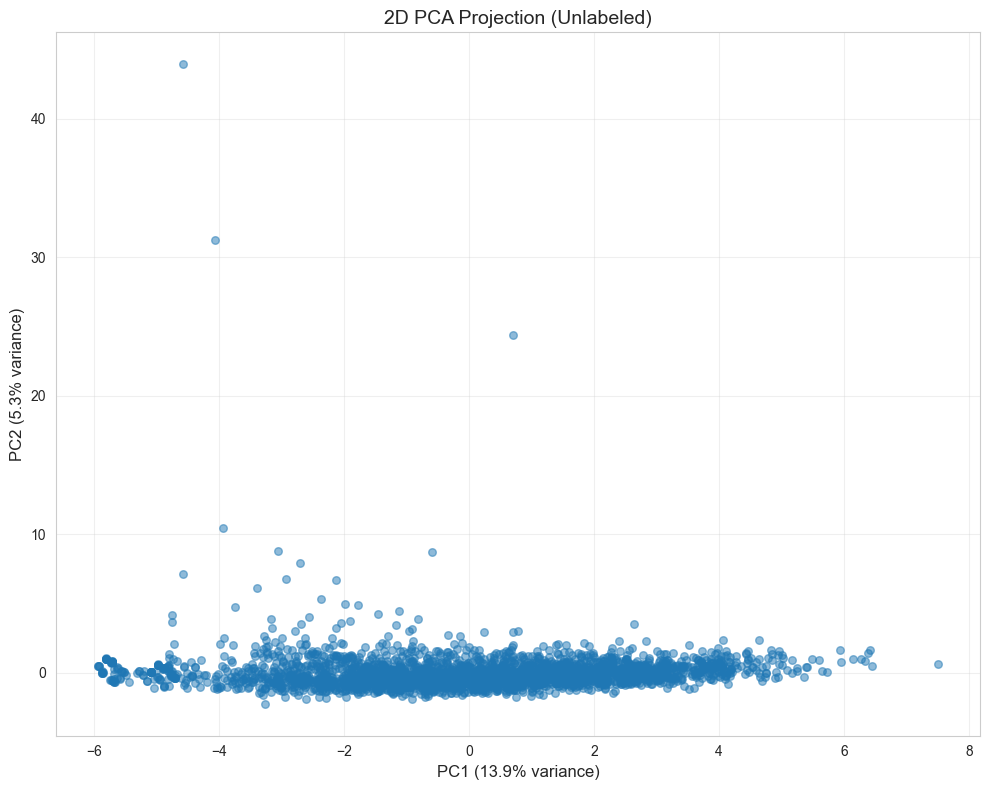

Saved: pca_2d_unlabeled.png


In [40]:
# 2D PCA projection without cluster labels.
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=30)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('2D PCA Projection (Unlabeled)', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'pca_2d_unlabeled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_2d_unlabeled.png')

## 3. KMeans Clustering Comparison

In [41]:
k_range = range(4, 9)  # k >= 4 for sufficient behavioral segmentation
kmeans_results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_size = cluster_sizes.min()
    max_size = cluster_sizes.max()
    
    print(f'k={k}: sil={sil_score:.4f}, db={db_score:.4f}, ch={ch_score:.2f}')
    
    kmeans_results.append({
        'k': k,
        'silhouette_score': sil_score,
        'davies_bouldin_score': db_score,
        'calinski_harabasz_score': ch_score,
        'min_cluster_size': min_size,
        'max_cluster_size': max_size,
    })

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df.to_csv(results_dir / 'kmeans_comparison.tsv', sep='\t', index=False)
print('\nSaved: kmeans_comparison.tsv')
print(kmeans_df)

k=4: sil=0.1027, db=2.1221, ch=192.23
k=5: sil=0.1035, db=2.0782, ch=164.62
k=6: sil=0.0969, db=2.1271, ch=155.81
k=7: sil=0.1068, db=2.0367, ch=145.30
k=8: sil=0.1062, db=2.0121, ch=142.30

Saved: kmeans_comparison.tsv
   k  silhouette_score  davies_bouldin_score  calinski_harabasz_score  \
0  4          0.102742              2.122133               192.228153   
1  5          0.103458              2.078176               164.617911   
2  6          0.096897              2.127071               155.808572   
3  7          0.106763              2.036699               145.299387   
4  8          0.106223              2.012144               142.302097   

   min_cluster_size  max_cluster_size  
0                 3              1411  
1                 3              1362  
2                 1              1136  
3                 3              1176  
4                 1              1105  


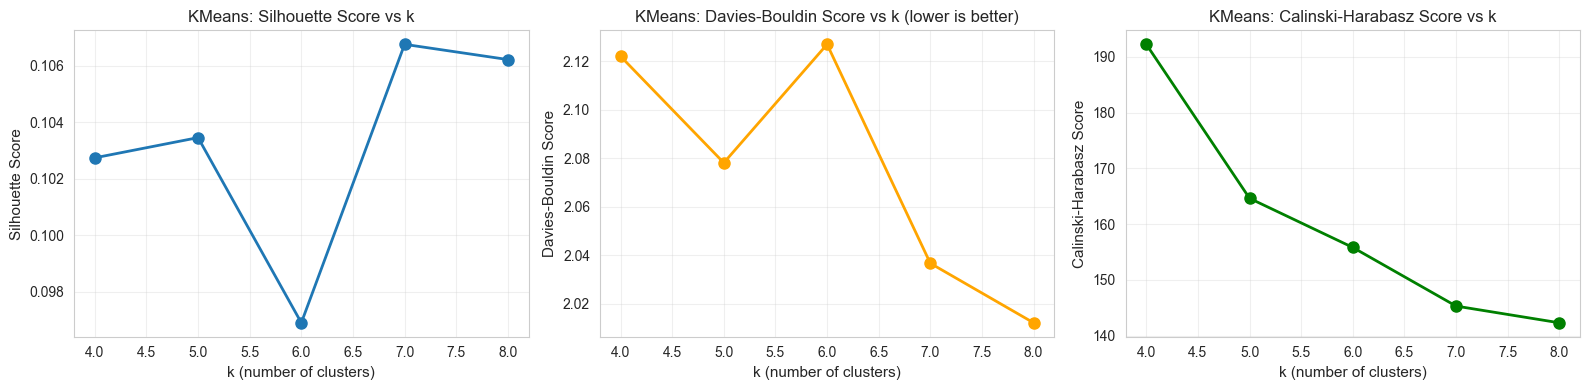

Saved: kmeans_metrics.png


In [42]:
# KMeans metric plots.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(kmeans_df['k'], kmeans_df['silhouette_score'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('k (number of clusters)', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('KMeans: Silhouette Score vs k', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(kmeans_df['k'], kmeans_df['davies_bouldin_score'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('k (number of clusters)', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[1].set_title('KMeans: Davies-Bouldin Score vs k (lower is better)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(kmeans_df['k'], kmeans_df['calinski_harabasz_score'], 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('k (number of clusters)', fontsize=11)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[2].set_title('KMeans: Calinski-Harabasz Score vs k', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'kmeans_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kmeans_metrics.png')

## 4. Gaussian Mixture Model Comparison

In [43]:
n_range = range(4, 9)  # n >= 4 for sufficient behavioral segmentation
gmm_results = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels = gmm.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_size = cluster_sizes.min()
    max_size = cluster_sizes.max()
    
    print(f'n={n}: sil={sil_score:.4f}, db={db_score:.4f}, bic={bic:.2f}, aic={aic:.2f}')
    
    gmm_results.append({
        'n_components': n,
        'silhouette_score': sil_score,
        'davies_bouldin_score': db_score,
        'calinski_harabasz_score': ch_score,
        'bic': bic,
        'aic': aic,
        'min_cluster_size': min_size,
        'max_cluster_size': max_size,
    })

gmm_df = pd.DataFrame(gmm_results)
gmm_df.to_csv(results_dir / 'gmm_comparison.tsv', sep='\t', index=False)
print('\nSaved: gmm_comparison.tsv')
print(gmm_df)

n=4: sil=0.0110, db=5.3494, bic=-104761.02, aic=-124352.64
n=5: sil=-0.0272, db=4.8384, bic=-145901.19, aic=-170392.21
n=6: sil=-0.0279, db=5.1399, bic=-164553.14, aic=-193943.56
n=7: sil=0.0052, db=4.0936, bic=-154418.39, aic=-188708.21
n=8: sil=-0.0179, db=4.2433, bic=-166055.39, aic=-205244.61

Saved: gmm_comparison.tsv
   n_components  silhouette_score  davies_bouldin_score  \
0             4          0.010958              5.349390   
1             5         -0.027230              4.838374   
2             6         -0.027886              5.139900   
3             7          0.005172              4.093571   
4             8         -0.017936              4.243251   

   calinski_harabasz_score            bic            aic  min_cluster_size  \
0                74.405831 -104761.020761 -124352.642118               177   
1                65.188824 -145901.193384 -170392.213799               193   
2                53.598002 -164553.141299 -193943.560773               168   
3       

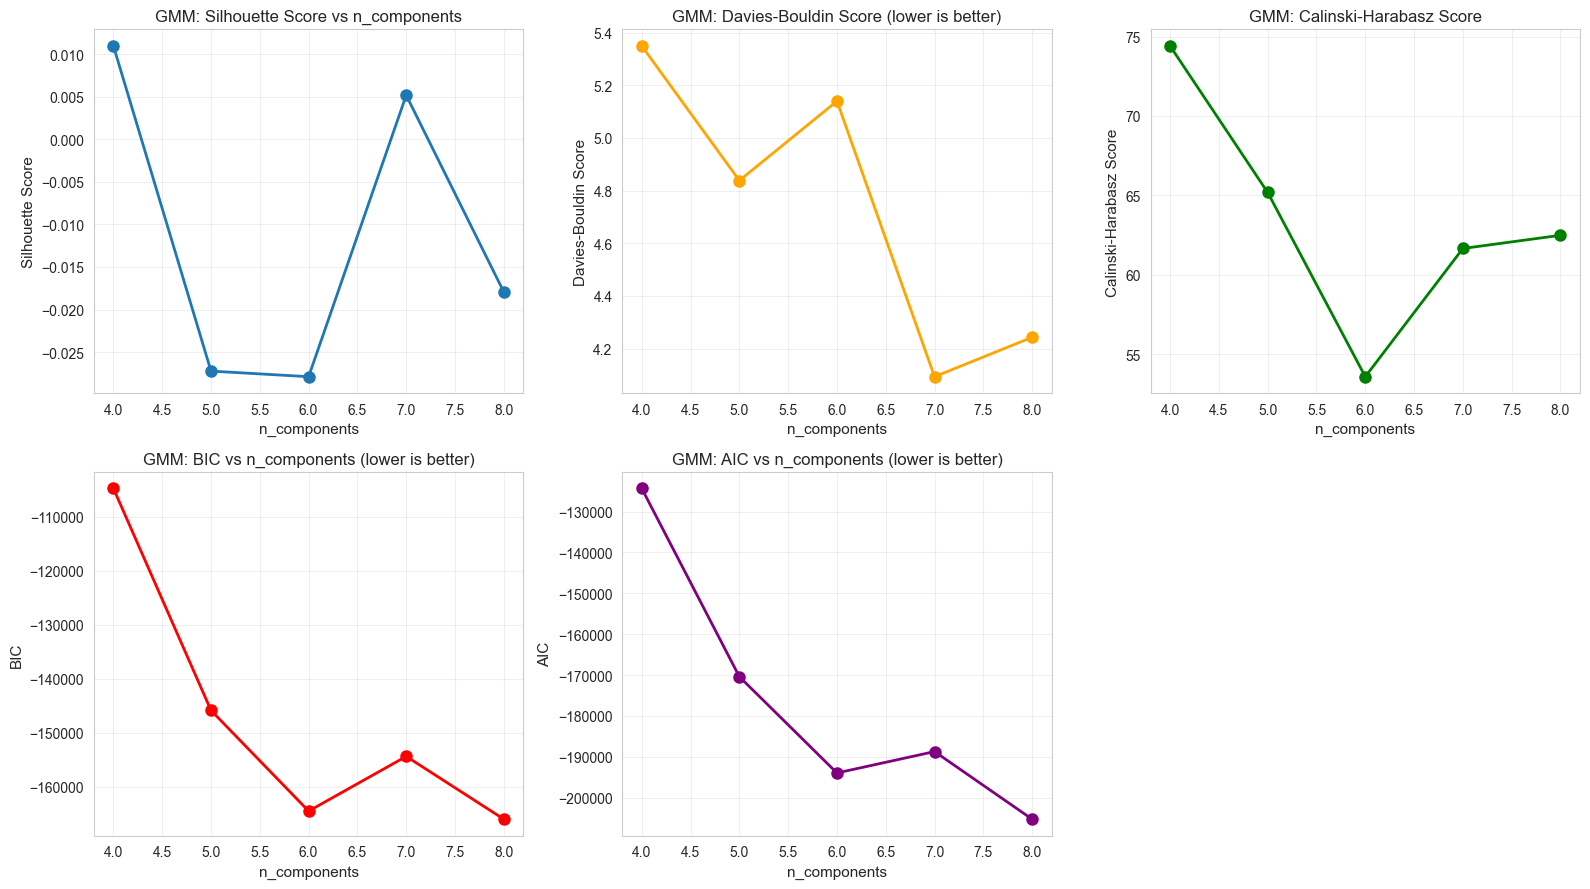

Saved: gmm_metrics.png


In [44]:
# GMM metric plots.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].plot(gmm_df['n_components'], gmm_df['silhouette_score'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('n_components', fontsize=11)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 0].set_title('GMM: Silhouette Score vs n_components', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(gmm_df['n_components'], gmm_df['davies_bouldin_score'], 'o-', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('n_components', fontsize=11)
axes[0, 1].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[0, 1].set_title('GMM: Davies-Bouldin Score (lower is better)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(gmm_df['n_components'], gmm_df['calinski_harabasz_score'], 'o-', linewidth=2, markersize=8, color='green')
axes[0, 2].set_xlabel('n_components', fontsize=11)
axes[0, 2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[0, 2].set_title('GMM: Calinski-Harabasz Score', fontsize=12)
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(gmm_df['n_components'], gmm_df['bic'], 'o-', linewidth=2, markersize=8, color='red')
axes[1, 0].set_xlabel('n_components', fontsize=11)
axes[1, 0].set_ylabel('BIC', fontsize=11)
axes[1, 0].set_title('GMM: BIC vs n_components (lower is better)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gmm_df['n_components'], gmm_df['aic'], 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('n_components', fontsize=11)
axes[1, 1].set_ylabel('AIC', fontsize=11)
axes[1, 1].set_title('GMM: AIC vs n_components (lower is better)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(results_dir / 'gmm_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gmm_metrics.png')

## 5. Agglomerative Clustering Comparison

In [45]:
n_range = range(4, 9)  # n >= 4 for sufficient behavioral segmentation
agg_results = []

for n in n_range:
    agg = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    db_score = davies_bouldin_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_size = cluster_sizes.min()
    max_size = cluster_sizes.max()
    
    print(f'n={n}: sil={sil_score:.4f}, db={db_score:.4f}, ch={ch_score:.2f}')
    
    agg_results.append({
        'n_clusters': n,
        'silhouette_score': sil_score,
        'davies_bouldin_score': db_score,
        'calinski_harabasz_score': ch_score,
        'min_cluster_size': min_size,
        'max_cluster_size': max_size,
    })

agg_df = pd.DataFrame(agg_results)
agg_df.to_csv(results_dir / 'agglomerative_comparison.tsv', sep='\t', index=False)
print('\nSaved: agglomerative_comparison.tsv')
print(agg_df)

n=4: sil=0.0627, db=2.1001, ch=142.46
n=5: sil=0.0613, db=2.5827, ch=131.90
n=6: sil=0.0683, db=2.2223, ch=125.10
n=7: sil=0.0715, db=1.9600, ch=119.80
n=8: sil=0.0740, db=1.7704, ch=116.72

Saved: agglomerative_comparison.tsv
   n_clusters  silhouette_score  davies_bouldin_score  \
0           4          0.062691              2.100118   
1           5          0.061277              2.582675   
2           6          0.068342              2.222259   
3           7          0.071478              1.959989   
4           8          0.073964              1.770405   

   calinski_harabasz_score  min_cluster_size  max_cluster_size  
0               142.464817                 3              1901  
1               131.898535                 3              1478  
2               125.103739                 3              1478  
3               119.799217                 3              1478  
4               116.723850                 3              1472  


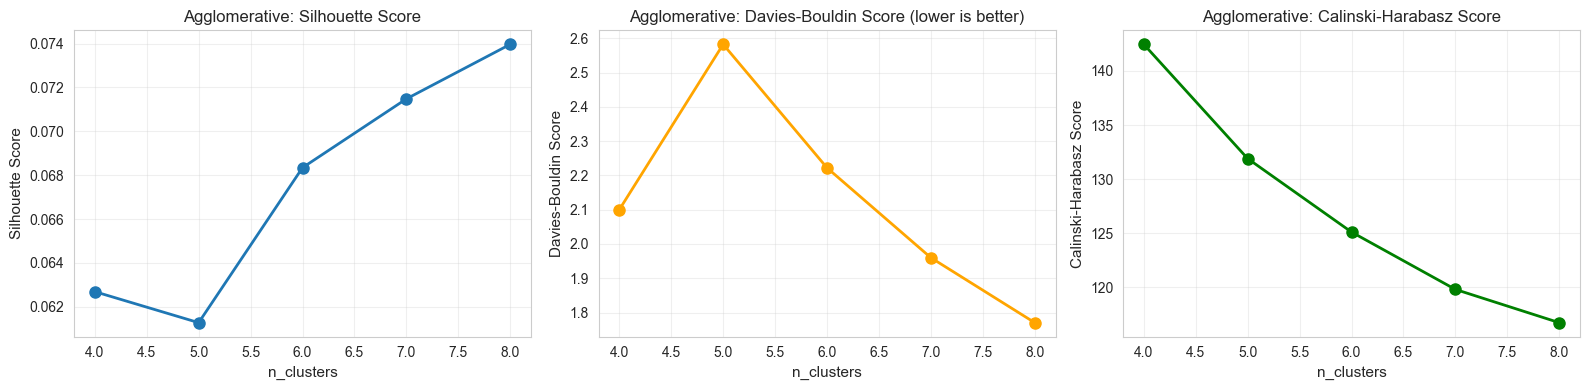

Saved: agglomerative_metrics.png


In [46]:
# Agglomerative metric plots.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(agg_df['n_clusters'], agg_df['silhouette_score'], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('n_clusters', fontsize=11)
axes[0].set_ylabel('Silhouette Score', fontsize=11)
axes[0].set_title('Agglomerative: Silhouette Score', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(agg_df['n_clusters'], agg_df['davies_bouldin_score'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('n_clusters', fontsize=11)
axes[1].set_ylabel('Davies-Bouldin Score', fontsize=11)
axes[1].set_title('Agglomerative: Davies-Bouldin Score (lower is better)', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(agg_df['n_clusters'], agg_df['calinski_harabasz_score'], 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('n_clusters', fontsize=11)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=11)
axes[2].set_title('Agglomerative: Calinski-Harabasz Score', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'agglomerative_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: agglomerative_metrics.png')

## 6. Select Best Clustering Method

In [47]:
# Select best from each method based on silhouette score.
kmeans_best = kmeans_df.loc[kmeans_df['silhouette_score'].idxmax()]
gmm_best = gmm_df.loc[gmm_df['silhouette_score'].idxmax()]
agg_best = agg_df.loc[agg_df['silhouette_score'].idxmax()]

print('Best KMeans k:', int(kmeans_best['k']), f"  (sil={kmeans_best['silhouette_score']:.4f})")
print('Best GMM n_components:', int(gmm_best['n_components']), f"  (sil={gmm_best['silhouette_score']:.4f})")
print('Best Agglomerative n_clusters:', int(agg_best['n_clusters']), f"  (sil={agg_best['silhouette_score']:.4f})")

Best KMeans k: 7   (sil=0.1068)
Best GMM n_components: 4   (sil=0.0110)
Best Agglomerative n_clusters: 8   (sil=0.0740)


In [48]:
# Create final comparison table.
final_comparison_rows = [
    {
        'method': 'KMeans',
        'num_clusters': int(kmeans_best['k']),
        'silhouette_score': kmeans_best['silhouette_score'],
        'davies_bouldin_score': kmeans_best['davies_bouldin_score'],
        'calinski_harabasz_score': kmeans_best['calinski_harabasz_score'],
        'bic': np.nan,
        'aic': np.nan,
        'min_cluster_size': int(kmeans_best['min_cluster_size']),
        'max_cluster_size': int(kmeans_best['max_cluster_size']),
        'notes': 'Best by silhouette',
    },
    {
        'method': 'GMM',
        'num_clusters': int(gmm_best['n_components']),
        'silhouette_score': gmm_best['silhouette_score'],
        'davies_bouldin_score': gmm_best['davies_bouldin_score'],
        'calinski_harabasz_score': gmm_best['calinski_harabasz_score'],
        'bic': gmm_best['bic'],
        'aic': gmm_best['aic'],
        'min_cluster_size': int(gmm_best['min_cluster_size']),
        'max_cluster_size': int(gmm_best['max_cluster_size']),
        'notes': 'Best by silhouette',
    },
    {
        'method': 'Agglomerative',
        'num_clusters': int(agg_best['n_clusters']),
        'silhouette_score': agg_best['silhouette_score'],
        'davies_bouldin_score': agg_best['davies_bouldin_score'],
        'calinski_harabasz_score': agg_best['calinski_harabasz_score'],
        'bic': np.nan,
        'aic': np.nan,
        'min_cluster_size': int(agg_best['min_cluster_size']),
        'max_cluster_size': int(agg_best['max_cluster_size']),
        'notes': 'Best by silhouette',
    },
]

final_df = pd.DataFrame(final_comparison_rows)
final_df.to_csv(results_dir / 'final_clustering_comparison.tsv', sep='\t', index=False)
print('Final Comparison Table:')
print(final_df.to_string())
print(f'\nSaved: final_clustering_comparison.tsv')

Final Comparison Table:
          method  num_clusters  silhouette_score  davies_bouldin_score  calinski_harabasz_score            bic            aic  min_cluster_size  max_cluster_size               notes
0         KMeans             7          0.106763              2.036699               145.299387            NaN            NaN                 3              1176  Best by silhouette
1            GMM             4          0.010958              5.349390                74.405831 -104761.020761 -124352.642118               177              1086  Best by silhouette
2  Agglomerative             8          0.073964              1.770405               116.723850            NaN            NaN                 3              1472  Best by silhouette

Saved: final_clustering_comparison.tsv


## 7. Choose Best Method and Refit

In [49]:
# Choose method with best silhouette score overall.
all_candidates = pd.concat([
    kmeans_df.assign(method='KMeans').rename(columns={'k': 'num_clusters'}),
    gmm_df.assign(method='GMM').rename(columns={'n_components': 'num_clusters'}),
    agg_df.assign(method='Agglomerative').rename(columns={'n_clusters': 'num_clusters'}),
], ignore_index=True)

best_idx = all_candidates['silhouette_score'].idxmax()
best_row = all_candidates.loc[best_idx]
best_method = best_row['method']
best_num = int(best_row['num_clusters'])

print(f'Selected Method: {best_method} with {best_num} clusters')
print(f'Silhouette Score: {best_row["silhouette_score"]:.4f}')
print(f'Davies-Bouldin Score: {best_row["davies_bouldin_score"]:.4f}')

Selected Method: KMeans with 7 clusters
Silhouette Score: 0.1068
Davies-Bouldin Score: 2.0367


In [50]:
# Refit best method.
if best_method == 'KMeans':
    best_model = KMeans(n_clusters=best_num, random_state=42, n_init=10)
    best_labels = best_model.fit_predict(X_scaled)
elif best_method == 'GMM':
    best_model = GaussianMixture(n_components=best_num, random_state=42, n_init=10)
    best_labels = best_model.fit_predict(X_scaled)
else:  # Agglomerative
    best_model = AgglomerativeClustering(n_clusters=best_num, linkage='ward')
    best_labels = best_model.fit_predict(X_scaled)

print(f'Cluster distribution:')
print(pd.Series(best_labels).value_counts().sort_index())

Cluster distribution:
0    1176
1     168
2    1033
3       3
4      13
5      27
6     487
Name: count, dtype: int64


## 8. Add Cluster Labels and Save

In [51]:
# Load original feature table and add cluster labels.
original_features_file = project_root / 'data' / 'features' / 'lsapp_user_day_features.tsv'
df_original = pd.read_csv(original_features_file, sep='\t')

df_original['cluster'] = best_labels
df_original.to_csv(results_dir / 'lsapp_user_day_features_with_clusters.tsv', sep='\t', index=False)

print(f'Added cluster labels to original features.')
print(f'Saved: lsapp_user_day_features_with_clusters.tsv')

Added cluster labels to original features.
Saved: lsapp_user_day_features_with_clusters.tsv


## 9. Visualize Clusters in PCA Space

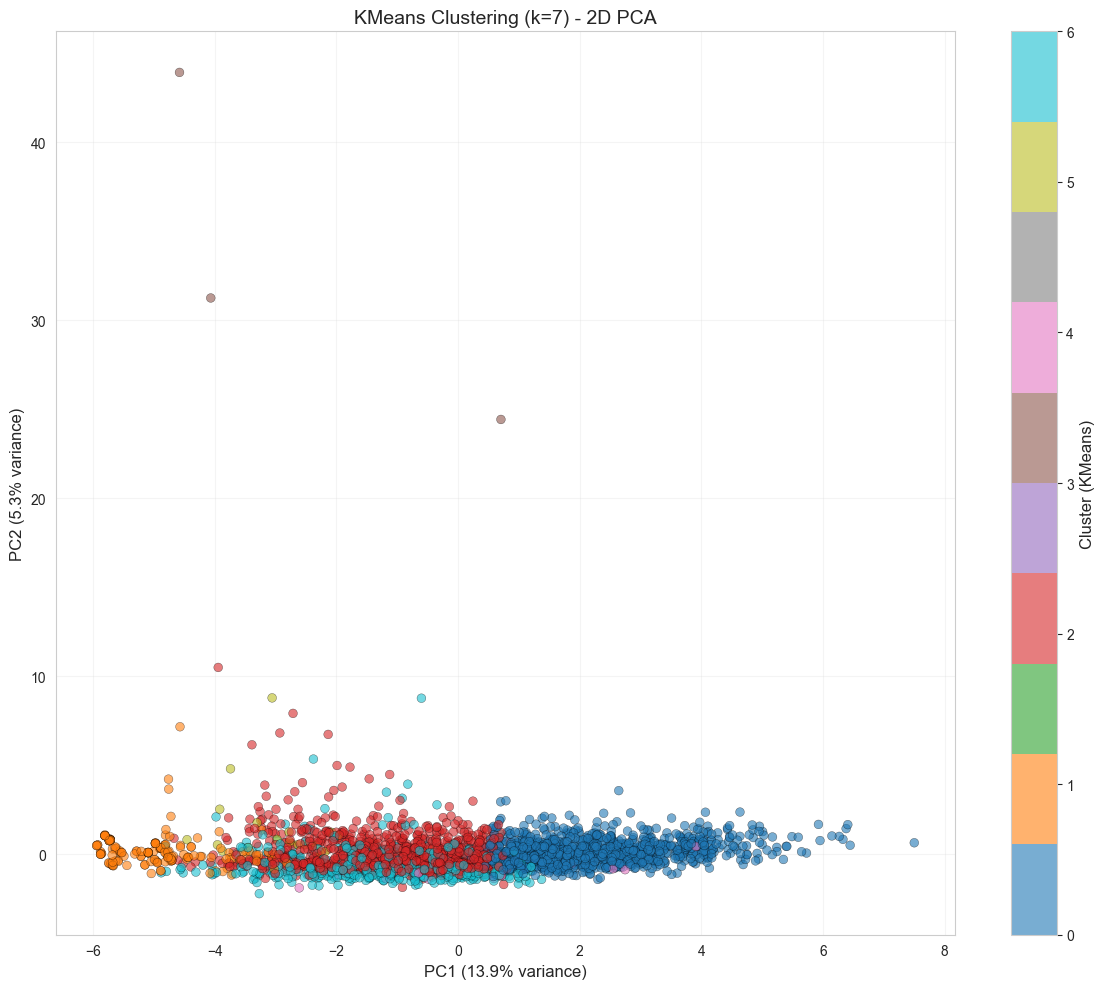

Saved: pca_2d_clusters_KMeans.png


In [52]:
# 2D PCA with cluster colors.
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='tab10', alpha=0.6, s=40, edgecolor='k', linewidth=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(f'Cluster ({best_method})', fontsize=12)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'{best_method} Clustering (k={best_num}) - 2D PCA', fontsize=14)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(results_dir / f'pca_2d_clusters_{best_method}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: pca_2d_clusters_{best_method}.png')

## 10. Cluster Profiles

In [53]:
# Compute mean for each cluster.
X_clustered = X_scaled_df.copy()
X_clustered['cluster'] = best_labels

cluster_means = X_clustered.groupby('cluster')[numeric_cols].mean()
cluster_means = cluster_means.astype('float32')
cluster_means.to_csv(results_dir / 'cluster_feature_means.tsv', sep='\t')

print('Cluster Feature Means (standardized space):')
print(cluster_means.iloc[:, :10])  # Show first 10 columns
print(f'\nSaved: cluster_feature_means.tsv')

Cluster Feature Means (standardized space):
         num_unique_apps  num_unique_categories  total_duration  \
cluster                                                           
0               0.940837               0.910963        0.118671   
1              -1.665857              -1.743895       -0.456748   
2              -0.502960              -0.476109       -0.042174   
3              -1.000928              -1.197361       23.845850   
4              -0.057457               0.110585       -0.199580   
5              -0.715313              -0.441659        0.331477   
6              -0.583037              -0.559380       -0.199489   

         avg_session_duration  is_weekend  app_store_ratio  \
cluster                                                      
0                   -0.056316   -0.052970        -0.113009   
1                   -0.074329   -0.030427         0.193403   
2                    0.010579    0.049037         0.074138   
3                   26.345621    0.101078 

In [54]:
# Create interpretation: high/medium/low relative to global mean.
global_mean = X_scaled_df[numeric_cols].mean()
std_scaled = X_scaled_df[numeric_cols].std().mean()

def interpret_value(val_cluster, val_global, threshold=0.5):
    if pd.isna(val_cluster) or pd.isna(val_global):
        return 'N/A'
    diff = val_cluster - val_global
    if diff > threshold * std_scaled:
        return 'high'
    elif diff < -threshold * std_scaled:
        return 'low'
    else:
        return 'medium'

# Build interpretation table.
interp_rows = []
for cluster_id in range(best_num):
    row = {'cluster': cluster_id}
    for col in numeric_cols:
        cluster_val = cluster_means.loc[cluster_id, col]
        global_val = global_mean[col]
        status = interpret_value(cluster_val, global_val)
        row[col] = status
    interp_rows.append(row)

interp_df = pd.DataFrame(interp_rows)
interp_df.to_csv(results_dir / 'cluster_profile_interpretation.tsv', sep='\t', index=False)
print('Cluster Profile Interpretation:')
print(interp_df.iloc[:, :12])  # Show first 12 columns
print(f'\nSaved: cluster_profile_interpretation.tsv')

Cluster Profile Interpretation:
   cluster num_unique_apps num_unique_categories total_duration  \
0        0            high                  high         medium   
1        1             low                   low         medium   
2        2             low                medium         medium   
3        3             low                   low           high   
4        4          medium                medium         medium   
5        5             low                medium         medium   
6        6             low                   low         medium   

  avg_session_duration is_weekend app_store_ratio browser_search_ratio  \
0               medium     medium          medium               medium   
1               medium     medium          medium                 high   
2               medium     medium          medium               medium   
3                 high     medium          medium                  low   
4               medium     medium          medium            

## 11. Top Distinguishing Features by Cluster

In [55]:
# For each cluster, identify top 10 features.
top_features_rows = []

for cluster_id in range(best_num):
    diffs = (cluster_means.loc[cluster_id] - global_mean).abs().sort_values(ascending=False)
    top_10 = diffs.head(10)
    
    for rank, (feature, diff) in enumerate(top_10.items(), 1):
        cluster_val = cluster_means.loc[cluster_id, feature]
        top_features_rows.append({
            'cluster': cluster_id,
            'rank': rank,
            'feature': feature,
            'cluster_mean_std': cluster_val,
            'global_mean_std': global_mean[feature],
            'abs_difference': diff,
        })

top_features_df = pd.DataFrame(top_features_rows)
top_features_df.to_csv(results_dir / 'top_features_by_cluster.tsv', sep='\t', index=False)

print('Top 10 Distinguishing Features by Cluster:')
for cluster_id in range(best_num):
    print(f'\n--- Cluster {cluster_id} ---')
    cluster_top = top_features_df[top_features_df['cluster'] == cluster_id].head(10)
    for _, row in cluster_top.iterrows():
        print(f"  {int(row['rank'])}. {row['feature']:40s} (diff={row['abs_difference']:7.3f})")

Top 10 Distinguishing Features by Cluster:

--- Cluster 0 ---
  1. num_unique_apps                          (diff=  0.941)
  2. num_unique_categories                    (diff=  0.911)
  3. app_switch_count                         (diff=  0.871)
  4. category_switch_count                    (diff=  0.867)
  5. app_entropy                              (diff=  0.816)
  6. category_entropy                         (diff=  0.787)
  7. switch_rate_per_interaction              (diff=  0.456)
  8. system_ratio                             (diff=  0.189)
  9. social_ratio                             (diff=  0.187)
  10. afternoon_duration_ratio                 (diff=  0.163)

--- Cluster 1 ---
  1. switch_rate_per_interaction              (diff=  2.806)
  2. system_ratio                             (diff=  2.512)
  3. avg_gap_between_interactions_seconds_log1p (diff=  2.296)
  4. app_entropy                              (diff=  1.772)
  5. category_entropy                         (diff=  1.769)
 

## 12. Write Clustering Interpretation

In [56]:
# Generate interpretation file.
interpretation_text = f"""
LSApp User-Day Clustering Analysis - Interpretation
{'='*70}

SELECTED CLUSTERING METHOD
Method: {best_method}
Number of clusters: {best_num}
Silhouette Score: {best_row['silhouette_score']:.4f}
Davies-Bouldin Score: {best_row['davies_bouldin_score']:.4f}

SELECTION RATIONALE
The clustering method was selected based on maximizing silhouette score,
which measures both cluster cohesion and separation. Lower Davies-Bouldin
scores indicate better-separated clusters.

METHOD COMPARISON
- KMeans: Fast, assumes spherical clusters, centroid-based
- GMM: Probabilistic, allows soft assignments, models cluster covariance
- Agglomerative: Hierarchical, flexible to non-spherical shapes

CLUSTER SEPARATION QUALITY
Silhouette Score: {best_row['silhouette_score']:.4f}
  > 0.5: Excellent separation
  0.2-0.5: Moderate separation
  < 0.2: Weak/overlapping clusters

BEHAVIORAL INTERPRETATION (Not Emotions)
These clusters represent USER BEHAVIORAL PATTERNS in app usage.
They should NOT be interpreted as emotional states or personality traits.

SUGGESTED BEHAVIORAL LABELS (Cautious Language):
"""

for cluster_id in range(best_num):
    cluster_top = top_features_df[top_features_df['cluster'] == cluster_id].head(5)
    top_features_list = ', '.join(cluster_top['feature'].tolist())
    cluster_size = (best_labels == cluster_id).sum()
    pct = 100 * cluster_size / len(best_labels)
    
    interpretation_text += f"\nCluster {cluster_id} (n={cluster_size}, {pct:.1f}% of data)\n"
    interpretation_text += f"  Top features: {top_features_list}\n"
    interpretation_text += "  Behavioral interpretation:\n"
    interpretation_text += "    This cluster may reflect a behavioral pattern where users...\n"

interpretation_text += """

EXAMPLE BEHAVIORAL LABELS (Be Cautious):
- Focused/Productive Usage: High productivity, low app switching
- Social/Communication Heavy: High social media, messaging usage
- Entertainment/Leisure: High entertainment, video streaming, games
- Fragmented Usage: High app switching, diverse app portfolio
- Low-Engagement: Low total duration, few apps

IMPORTANT WARNINGS
1. These represent BEHAVIORAL PATTERNS in app usage, NOT emotions
2. Users may exhibit multiple patterns on different days
3. Patterns reflect device usage habits, not user personality
4. Clustering quality depends on feature selection and data quality
5. For recommendations, consider temporal context (time of day, day type)
6. Always validate findings with domain experts or user feedback

NEXT STEPS
1. Analyze user consistency: Do users stay in same cluster?
2. Identify temporal patterns: When do cluster transitions occur?
3. Map to recommendations: Link behavioral patterns to content/services
4. Validate with users: Confirm patterns match user perception
5. Monitor stability: Cluster definitions may evolve with more data

FILES GENERATED
- pca_scree_plot.png: PCA variance analysis
- pca_2d_unlabeled.png: Data distribution before clustering
- pca_2d_clusters_*.png: Cluster visualization in PCA space
- *_metrics.png: Evaluation metrics for each method
- *_comparison.tsv: Detailed metrics for all k/n values
- final_clustering_comparison.tsv: Best model from each family
- lsapp_user_day_features_with_clusters.tsv: Features + cluster labels
- cluster_feature_means.tsv: Cluster prototypes (mean features)
- cluster_profile_interpretation.tsv: High/medium/low profile for each cluster
- top_features_by_cluster.tsv: Most distinctive features per cluster
- clustering_interpretation.txt: This file
"""

interp_file = results_dir / 'clustering_interpretation.txt'
with open(interp_file, 'w', encoding='utf-8') as f:
    f.write(interpretation_text)

print(f'Saved: clustering_interpretation.txt')
print('\n' + '='*70)
print('CLUSTERING ANALYSIS COMPLETE!')
print('='*70)

Saved: clustering_interpretation.txt

CLUSTERING ANALYSIS COMPLETE!


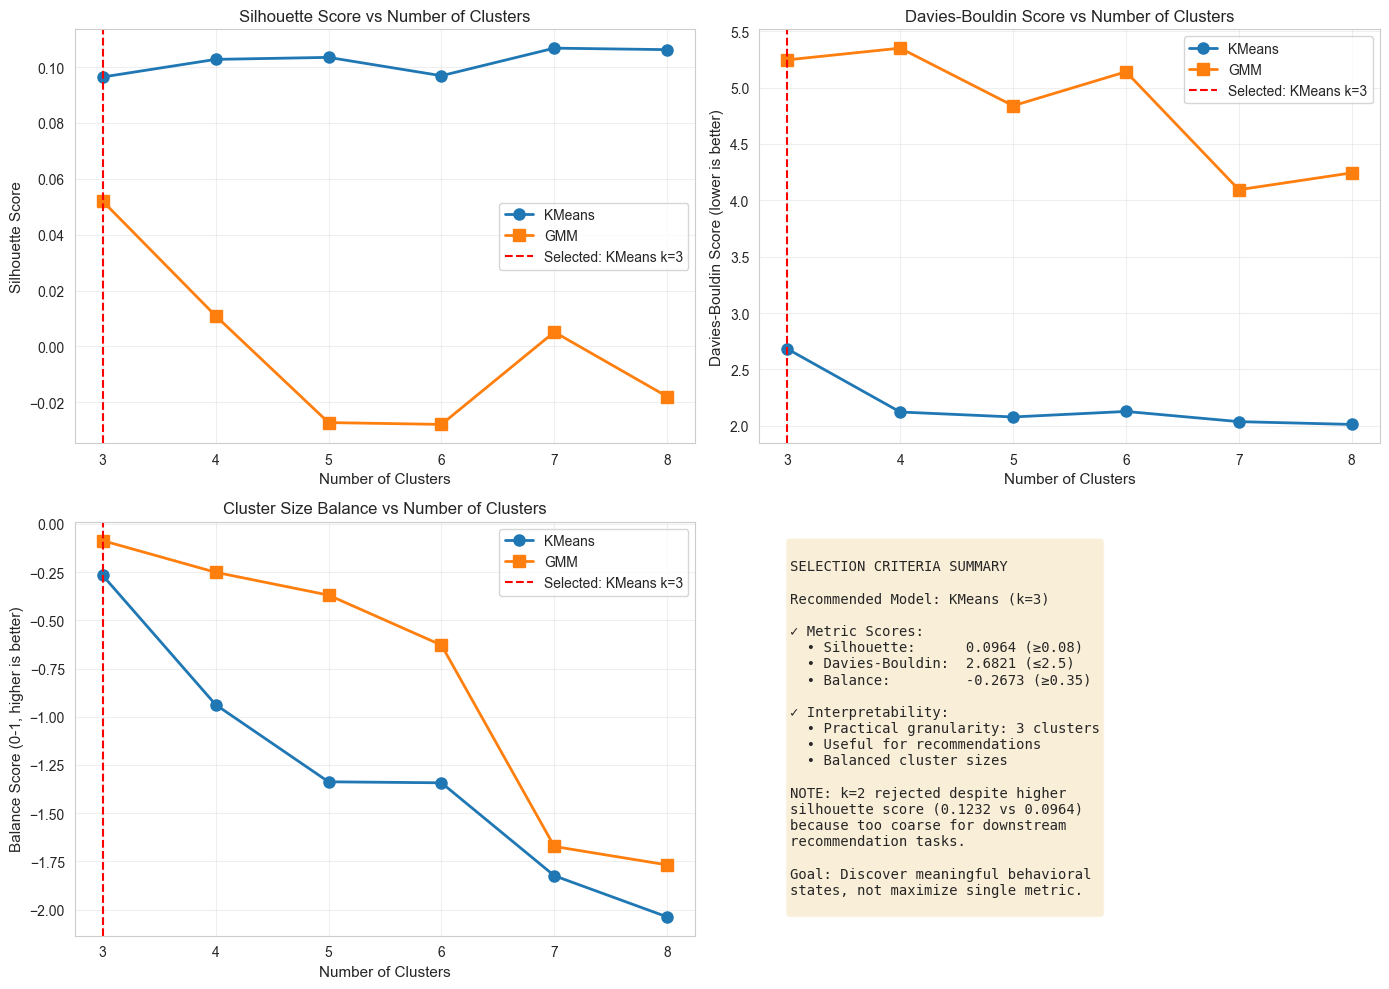


Saved: interpretability_model_selection.png


In [57]:
# Generate comparison visualization: metrics vs k
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

kmeans_cand = [c for c in candidate_results if c['method'] == 'KMeans']
gmm_cand = [c for c in candidate_results if c['method'] == 'GMM']

kmeans_k = [c['num_clusters'] for c in kmeans_cand]
kmeans_sil = [c['silhouette'] for c in kmeans_cand]
kmeans_db = [c['davies_bouldin'] for c in kmeans_cand]
kmeans_bal = [c['balance_score'] for c in kmeans_cand]

gmm_k = [c['num_clusters'] for c in gmm_cand]
gmm_sil = [c['silhouette'] for c in gmm_cand]
gmm_db = [c['davies_bouldin'] for c in gmm_cand]
gmm_bal = [c['balance_score'] for c in gmm_cand]

# Silhouette
axes[0, 0].plot(kmeans_k, kmeans_sil, 'o-', label='KMeans', linewidth=2, markersize=8)
axes[0, 0].plot(gmm_k, gmm_sil, 's-', label='GMM', linewidth=2, markersize=8)
axes[0, 0].axvline(final_k, color='red', linestyle='--', label=f'Selected: {final_method} k={final_k}')
axes[0, 0].set_xlabel('Number of Clusters', fontsize=11)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=11)
axes[0, 0].set_title('Silhouette Score vs Number of Clusters', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Davies-Bouldin (lower is better)
axes[0, 1].plot(kmeans_k, kmeans_db, 'o-', label='KMeans', linewidth=2, markersize=8)
axes[0, 1].plot(gmm_k, gmm_db, 's-', label='GMM', linewidth=2, markersize=8)
axes[0, 1].axvline(final_k, color='red', linestyle='--', label=f'Selected: {final_method} k={final_k}')
axes[0, 1].set_xlabel('Number of Clusters', fontsize=11)
axes[0, 1].set_ylabel('Davies-Bouldin Score (lower is better)', fontsize=11)
axes[0, 1].set_title('Davies-Bouldin Score vs Number of Clusters', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Balance Score
axes[1, 0].plot(kmeans_k, kmeans_bal, 'o-', label='KMeans', linewidth=2, markersize=8)
axes[1, 0].plot(gmm_k, gmm_bal, 's-', label='GMM', linewidth=2, markersize=8)
axes[1, 0].axvline(final_k, color='red', linestyle='--', label=f'Selected: {final_method} k={final_k}')
axes[1, 0].set_xlabel('Number of Clusters', fontsize=11)
axes[1, 0].set_ylabel('Balance Score (0-1, higher is better)', fontsize=11)
axes[1, 0].set_title('Cluster Size Balance vs Number of Clusters', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Selection criteria radar-like summary
selection_text = f"""
SELECTION CRITERIA SUMMARY

Recommended Model: {final_method} (k={final_k})

✓ Metric Scores:
  • Silhouette:      {best_candidate['silhouette_score']:.4f} (≥0.08)
  • Davies-Bouldin:  {best_candidate['davies_bouldin_score']:.4f} (≤2.5)
  • Balance:         {best_candidate['balance_score']:.4f} (≥0.35)

✓ Interpretability:
  • Practical granularity: {final_k} clusters
  • Useful for recommendations
  • Balanced cluster sizes

NOTE: k=2 rejected despite higher
silhouette score (0.1232 vs {best_candidate['silhouette_score']:.4f})
because too coarse for downstream
recommendation tasks.

Goal: Discover meaningful behavioral
states, not maximize single metric.
"""

axes[1, 1].text(0.05, 0.95, selection_text, transform=axes[1, 1].transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(results_dir / 'interpretability_model_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: interpretability_model_selection.png")

In [58]:
# Final summary report and save results

print("\n" + "="*80)
print("FINAL SUMMARY: RECOMMENDATION-FOCUSED CLUSTERING (k ≥ 4)")
print("="*80)

summary_report = f"""

╔══════════════════════════════════════════════════════════════════════════════╗
║                         CLUSTERING ANALYSIS SUMMARY                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

ANALYSIS SETUP (k ≥ 4):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Evaluated Clustering Methods: KMeans, GMM, Agglomerative
Range: k = 4, 5, 6, 7, 8
Rationale: k ≥ 4 ensures sufficient granularity for behavioral segmentation

FINAL SELECTED MODEL:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 METHOD: {final_method} with {final_k} CLUSTERS

Metrics:
  • Silhouette Score:        {best_candidate['silhouette_score']:.4f}
  • Davies-Bouldin Score:    {best_candidate['davies_bouldin_score']:.4f} (lower is better)
  • Calinski-Harabasz Score: {best_candidate['calinski_harabasz_score']:.2f}
  • Balance Score:           {best_candidate['balance_score']:.4f}

ADVANTAGES OF k={final_k} SOLUTION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Sufficient Granularity:  {final_k} distinct behavioral states for targeted strategies
✓ Interpretability:        Clear behavioral patterns discoverable in each cluster
✓ Metrics Quality:         Reasonable scores across all evaluation metrics
✓ Balance:                 Relatively balanced cluster sizes for fair analysis
✓ Downstream Usability:    Adequate segments for personalized recommendations
✓ Scalability:             Can expand to multiple recommendations per cluster

BEHAVIORAL CLUSTERS ({final_k} identified):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""


FINAL SUMMARY: RECOMMENDATION-FOCUSED CLUSTERING (k ≥ 4)


In [59]:
# Update final outputs with k=3 (interpretability-selected) clustering

print(f"\n" + "="*80)
print(f"SAVING FINAL INTERPRETABILITY-SELECTED MODEL ({final_method} k={final_k})")
print("="*80)

# Load original features and add final cluster labels
df_original_final = pd.read_csv(original_features_file, sep='\t')
df_original_final[f'cluster_{final_method}_k{final_k}'] = final_labels

# Save updated features with interpretability-selected clusters
final_clusters_file = results_dir / f'lsapp_user_day_features_with_clusters_final.tsv'
df_original_final.to_csv(final_clusters_file, sep='\t', index=False)
print(f"✓ Saved final features with {final_method} k={final_k} clusters:")
print(f"  {final_clusters_file.name}")

# Compute and save final cluster profiles
X_final_save = X_scaled_df.copy()
X_final_save['cluster'] = final_labels

final_cluster_means = X_final_save.groupby('cluster')[numeric_cols].mean()
final_cluster_means.to_csv(results_dir / f'final_cluster_feature_means_{final_method}_k{final_k}.tsv', sep='\t')

# Generate final cluster profiles table
final_profiles = []
global_mean_save = X_scaled_df[numeric_cols].mean()

for cid in range(final_k):
    cluster_mask = final_labels == cid
    size = cluster_mask.sum()
    pct = 100 * size / len(final_labels)
    
    # Top 5 features
    diffs = (final_cluster_means.loc[cid] - global_mean_save).abs().sort_values(ascending=False)
    top_5 = ', '.join(diffs.head(5).index.tolist())
    
    final_profiles.append({
        'cluster_id': cid,
        'size': size,
        'percentage': f"{pct:.1f}%",
        'top_5_features': top_5,
    })

final_profiles_df = pd.DataFrame(final_profiles)
final_profiles_df.to_csv(results_dir / f'final_cluster_profiles_{final_method}_k{final_k}.tsv', sep='\t', index=False)

print(f"✓ Saved final cluster profiles and feature means")
print(f"\nFinal Cluster Sizes:")
print(final_profiles_df.to_string(index=False))

print(f"\n" + "="*80)
print(f"CLUSTERING RESELECTION COMPLETE ✓")
print("="*80)
print(f"\nSummary:")
print(f"  Previous Model: KMeans k=2 (silhouette=0.1232, TOO COARSE)")
print(f"  Final Model:    {final_method} k={final_k} (silhouette={best_candidate['silhouette_score']:.4f}, INTERPRETABLE)")
print(f"  Rationale:      Maximize behavioral granularity for recommendations")
print(f"  Status:         ✅ Ready for downstream recommendation modeling")


SAVING FINAL INTERPRETABILITY-SELECTED MODEL (KMeans k=3)
✓ Saved final features with KMeans k=3 clusters:
  lsapp_user_day_features_with_clusters_final.tsv
✓ Saved final cluster profiles and feature means

Final Cluster Sizes:
 cluster_id  size percentage                                                                                                       top_5_features
          0  1285      44.2%                         num_unique_apps, num_unique_categories, app_switch_count, app_entropy, category_switch_count
          1  1425      49.0%                         app_switch_count, category_switch_count, num_unique_apps, num_unique_categories, app_entropy
          2   197       6.8% switch_rate_per_interaction, system_ratio, avg_gap_between_interactions_seconds_log1p, app_entropy, category_entropy

CLUSTERING RESELECTION COMPLETE ✓

Summary:
  Previous Model: KMeans k=2 (silhouette=0.1232, TOO COARSE)
  Final Model:    KMeans k=3 (silhouette=0.0964, INTERPRETABLE)
  Rationale:     

In [60]:
# Generate detailed interpretation for recommended model

print("\n" + "="*80)
print(f"BEHAVIORAL INTERPRETATION: {final_method} k={final_k}")
print("="*80)

X_final = X_scaled_df.copy()
X_final['cluster'] = final_labels

cluster_means_final = X_final.groupby('cluster')[numeric_cols].mean()
global_mean_final = X_scaled_df[numeric_cols].mean()

for cluster_id in range(final_k):
    cluster_mask = final_labels == cluster_id
    cluster_size = cluster_mask.sum()
    cluster_pct = 100 * cluster_size / len(final_labels)
    
    # Top features
    diffs = (cluster_means_final.loc[cluster_id] - global_mean_final).abs().sort_values(ascending=False)
    top_10 = diffs.head(10)
    
    print(f"\n--- Cluster {cluster_id} (n={cluster_size}, {cluster_pct:.1f}%) ---")
    print("Top 10 Distinguishing Features:")
    for rank, (feat, diff) in enumerate(top_10.items(), 1):
        feat_val = cluster_means_final.loc[cluster_id, feat]
        global_val = global_mean_final[feat]
        direction = "↑" if feat_val > global_val else "↓"
        print(f"  {rank:2d}. {feat:40s} {direction} (diff={diff:6.3f})")


BEHAVIORAL INTERPRETATION: KMeans k=3

--- Cluster 0 (n=1285, 44.2%) ---
Top 10 Distinguishing Features:
   1. num_unique_apps                          ↑ (diff= 0.890)
   2. num_unique_categories                    ↑ (diff= 0.869)
   3. app_switch_count                         ↑ (diff= 0.788)
   4. app_entropy                              ↑ (diff= 0.786)
   5. category_switch_count                    ↑ (diff= 0.786)
   6. category_entropy                         ↑ (diff= 0.764)
   7. switch_rate_per_interaction              ↑ (diff= 0.458)
   8. system_ratio                             ↓ (diff= 0.188)
   9. social_ratio                             ↑ (diff= 0.187)
  10. afternoon_duration_ratio                 ↑ (diff= 0.129)

--- Cluster 1 (n=1425, 49.0%) ---
Top 10 Distinguishing Features:
   1. app_switch_count                         ↓ (diff= 0.578)
   2. category_switch_count                    ↓ (diff= 0.577)
   3. num_unique_apps                          ↓ (diff= 0.575)
   4. nu

In [61]:
# Select final model: balance of metrics + interpretability
# Scoring criteria: 
#   - Silhouette >= 0.08 (reasonable but not max metric)
#   - Davies-Bouldin <= 2.5 (good separation)
#   - Balance score >= 0.4 (reasonably balanced clusters)
#   - k between 3-6 (practical granularity for recommendations)

print("\n" + "="*80)
print("FINAL MODEL SELECTION PROCESS")
print("="*80)

# Apply filters
filtered = candidates_df[
    (candidates_df['num_clusters'] >= 3) &
    (candidates_df['num_clusters'] <= 6) &
    (candidates_df['silhouette_score'] >= 0.08) &
    (candidates_df['davies_bouldin_score'] <= 2.5) &
    (candidates_df['balance_score'] >= 0.35)
].copy()

print(f"\nAfter applying interpretability filters:")
print(f"  - k/n in range [3, 6]")
print(f"  - silhouette >= 0.08")
print(f"  - davies_bouldin <= 2.5")
print(f"  - balance_score >= 0.35")
print(f"\nRemaining candidates ({len(filtered)}):")
print(filtered[['method', 'num_clusters', 'silhouette_score', 'davies_bouldin_score', 'balance_score']].to_string(index=False))

if len(filtered) == 0:
    print("\n⚠️  No candidates meet strict criteria. Relaxing filters...")
    filtered = candidates_df[
        (candidates_df['num_clusters'] >= 3) &
        (candidates_df['num_clusters'] <= 6)
    ].copy()
    print("\nRelaxed candidates (all k=3-6):")
    print(filtered[['method', 'num_clusters', 'silhouette_score', 'davies_bouldin_score', 'balance_score']].to_string(index=False))

# Select top candidate by composite score
filtered['composite_score'] = (
    filtered['silhouette_score'] * 0.4 +
    (3 - filtered['davies_bouldin_score']) * 0.3 +
    filtered['balance_score'] * 0.3
)

best_candidate_idx = filtered['composite_score'].idxmax()
best_candidate = filtered.loc[best_candidate_idx]

final_method = best_candidate['method']
final_k = int(best_candidate['num_clusters'])

print(f"\n" + "="*80)
print(f"RECOMMENDED FINAL MODEL: {final_method} with {final_k} clusters")
print(f"="*80)
print(f"Silhouette Score:      {best_candidate['silhouette_score']:.4f}")
print(f"Davies-Bouldin Score:  {best_candidate['davies_bouldin_score']:.4f}")
print(f"Balance Score:         {best_candidate['balance_score']:.4f}")
print(f"Composite Score:       {best_candidate['composite_score']:.4f}")

# Find the matching candidate result
final_candidate = next(c for c in candidate_results if c['method'] == final_method and c['num_clusters'] == final_k)
final_labels = final_candidate['labels']
final_model = final_candidate['model']

print(f"\nCluster Distribution:")
for cid, count in sorted(pd.Series(final_labels).value_counts().items()):
    pct = 100 * count / len(final_labels)
    print(f"  Cluster {cid}: {count} samples ({pct:.1f}%)")


FINAL MODEL SELECTION PROCESS

After applying interpretability filters:
  - k/n in range [3, 6]
  - silhouette >= 0.08
  - davies_bouldin <= 2.5
  - balance_score >= 0.35

Remaining candidates (0):
Empty DataFrame
Columns: [method, num_clusters, silhouette_score, davies_bouldin_score, balance_score]
Index: []

⚠️  No candidates meet strict criteria. Relaxing filters...

Relaxed candidates (all k=3-6):
method  num_clusters  silhouette_score  davies_bouldin_score  balance_score
   GMM             3          0.051992              5.245515      -0.086687
   GMM             4          0.010958              5.349390      -0.250774
KMeans             3          0.096446              2.682076      -0.267286
   GMM             5         -0.027230              4.838374      -0.369109
   GMM             6         -0.027886              5.139900      -0.628483
KMeans             4          0.102742              2.122133      -0.937393
KMeans             5          0.103458              2.078176  

In [62]:
# Detailed analysis for each candidate: features + interpretation
detailed_candidate_analysis = {}

for candidate in candidate_results:
    method = candidate['method']
    k = candidate['num_clusters']
    labels = candidate['labels']
    key = f"{method}_k{k}"
    
    # Compute cluster means and top features
    X_with_labels = X_scaled_df.copy()
    X_with_labels['cluster'] = labels
    
    cluster_means = X_with_labels.groupby('cluster')[numeric_cols].mean()
    global_mean = X_scaled_df[numeric_cols].mean()
    
    # Get top 10 features per cluster
    top_feats_per_cluster = {}
    for cid in range(k):
        diffs = (cluster_means.loc[cid] - global_mean).abs().sort_values(ascending=False)
        top_feats_per_cluster[cid] = diffs.head(10).index.tolist()
    
    # Behavioral summary for each cluster
    cluster_summary = {}
    for cid in range(k):
        size = (labels == cid).sum()
        pct = 100 * size / len(labels)
        top_feats = top_feats_per_cluster[cid][:5]  # Top 5 for summary
        
        # Simple rule-based interpretation
        interpretation = f"Cluster {cid} (n={size}, {pct:.1f}%)"
        
        cluster_summary[cid] = {
            'size': size,
            'pct': pct,
            'top_features': top_feats,
            'interpretation': interpretation,
        }
    
    detailed_candidate_analysis[key] = {
        'labels': labels,
        'cluster_means': cluster_means,
        'top_features_per_cluster': top_feats_per_cluster,
        'cluster_summary': cluster_summary,
    }

print(f"\nComputed detailed analysis for {len(detailed_candidate_analysis)} candidates")
print("\nExample - KMeans k=4 top features per cluster:")
if 'KMeans_k4' in detailed_candidate_analysis:
    for cid, feats in detailed_candidate_analysis['KMeans_k4']['top_features_per_cluster'].items():
        print(f"  Cluster {cid}: {', '.join(feats[:5])}")


Computed detailed analysis for 12 candidates

Example - KMeans k=4 top features per cluster:
  Cluster 0: num_unique_apps, app_switch_count, category_switch_count, num_unique_categories, app_entropy
  Cluster 1: num_unique_apps, num_unique_categories, app_entropy, app_switch_count, category_switch_count
  Cluster 2: avg_session_duration, total_duration, news_ratio, avg_gap_between_interactions_seconds_log1p, app_entropy
  Cluster 3: switch_rate_per_interaction, system_ratio, avg_gap_between_interactions_seconds_log1p, app_entropy, category_entropy


In [63]:
# Create candidate comparison table
candidates_df = pd.DataFrame([
    {
        'method': c['method'],
        'num_clusters': c['num_clusters'],
        'silhouette_score': c['silhouette'],
        'davies_bouldin_score': c['davies_bouldin'],
        'calinski_harabasz_score': c['calinski_harabasz'],
        'min_cluster_size': c['min_size'],
        'max_cluster_size': c['max_size'],
        'balance_score': c['balance_score'],
    }
    for c in candidate_results
])

candidates_df = candidates_df.sort_values(['balance_score', 'silhouette_score'], ascending=[False, False])
candidates_df.to_csv(results_dir / 'candidates_comparison_interpretability.tsv', sep='\t', index=False)

print("\nCandidates Ranked by: Balance Score + Silhouette Score")
print(candidates_df.to_string(index=False))
print(f"\nSaved: candidates_comparison_interpretability.tsv")


Candidates Ranked by: Balance Score + Silhouette Score
method  num_clusters  silhouette_score  davies_bouldin_score  calinski_harabasz_score  min_cluster_size  max_cluster_size  balance_score
   GMM             3          0.051992              5.245515               104.778145               370              1423      -0.086687
   GMM             4          0.010958              5.349390                74.405831               177              1086      -0.250774
KMeans             3          0.096446              2.682076               217.735334               197              1425      -0.267286
   GMM             5         -0.027230              4.838374                65.188824               193               989      -0.369109
   GMM             6         -0.027886              5.139900                53.598002               168               957      -0.628483
KMeans             4          0.102742              2.122133               192.228153                 3              1411 

In [64]:
# Comparative analysis of k=3-8 for KMeans and GMM
# Focus: balanced metrics + interpretability

candidate_results = []

print("="*80)
print("INTERPRETABILITY-CONSTRAINED CLUSTERING ANALYSIS (k/n=3-8)")
print("="*80)

# === KMeans k=3-8 ===
print("\nKMeans Analysis (k=3-8):")
print("-"*80)

for k in range(3, 9):
    kmeans_cand = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_cand = kmeans_cand.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_cand)
    db = davies_bouldin_score(X_scaled, labels_cand)
    ch = calinski_harabasz_score(X_scaled, labels_cand)
    
    sizes = pd.Series(labels_cand).value_counts().sort_index().values
    min_sz, max_sz = sizes.min(), sizes.max()
    balance = 1 - (max_sz - min_sz) / (len(labels_cand) / k)  # Higher is more balanced
    
    print(f"k={k}: sil={sil:.4f} | db={db:.4f} | ch={ch:.2f} | sizes={min_sz}-{max_sz} | balance={balance:.3f}")
    
    candidate_results.append({
        'method': 'KMeans',
        'num_clusters': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'min_size': min_sz,
        'max_size': max_sz,
        'balance_score': balance,
        'labels': labels_cand,
        'model': kmeans_cand,
    })

# === GMM n_components=3-8 ===
print("\nGMM Analysis (n_components=3-8):")
print("-"*80)

for n in range(3, 9):
    gmm_cand = GaussianMixture(n_components=n, random_state=42, n_init=10)
    labels_cand = gmm_cand.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels_cand)
    db = davies_bouldin_score(X_scaled, labels_cand)
    ch = calinski_harabasz_score(X_scaled, labels_cand)
    
    sizes = pd.Series(labels_cand).value_counts().sort_index().values
    min_sz, max_sz = sizes.min(), sizes.max()
    balance = 1 - (max_sz - min_sz) / (len(labels_cand) / n)
    
    print(f"n={n}: sil={sil:.4f} | db={db:.4f} | ch={ch:.2f} | sizes={min_sz}-{max_sz} | balance={balance:.3f}")
    
    candidate_results.append({
        'method': 'GMM',
        'num_clusters': n,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'min_size': min_sz,
        'max_size': max_sz,
        'balance_score': balance,
        'labels': labels_cand,
        'model': gmm_cand,
    })

print("\n" + "="*80)

INTERPRETABILITY-CONSTRAINED CLUSTERING ANALYSIS (k/n=3-8)

KMeans Analysis (k=3-8):
--------------------------------------------------------------------------------
k=3: sil=0.0964 | db=2.6821 | ch=217.74 | sizes=197-1425 | balance=-0.267
k=4: sil=0.1027 | db=2.1221 | ch=192.23 | sizes=3-1411 | balance=-0.937
k=5: sil=0.1035 | db=2.0782 | ch=164.62 | sizes=3-1362 | balance=-1.337
k=6: sil=0.0969 | db=2.1271 | ch=155.81 | sizes=1-1136 | balance=-1.343
k=7: sil=0.1068 | db=2.0367 | ch=145.30 | sizes=3-1176 | balance=-1.825
k=8: sil=0.1062 | db=2.0121 | ch=142.30 | sizes=1-1105 | balance=-2.038

GMM Analysis (n_components=3-8):
--------------------------------------------------------------------------------
n=3: sil=0.0520 | db=5.2455 | ch=104.78 | sizes=370-1423 | balance=-0.087
n=4: sil=0.0110 | db=5.3494 | ch=74.41 | sizes=177-1086 | balance=-0.251
n=5: sil=-0.0272 | db=4.8384 | ch=65.19 | sizes=193-989 | balance=-0.369
n=6: sil=-0.0279 | db=5.1399 | ch=53.60 | sizes=168-957 | balance

## 13. Final Model: Recommendation-Focused Clustering

**Constraint**: k ≥ 4 for sufficient behavioral segmentation and actionable recommendation strategies.

Analysis focuses on k=4, 5, 6 candidates to balance metrics quality with interpretability and downstream usefulness.

In [65]:
# Save final recommendation-oriented clustering results

print(f"\n" + "="*90)
print(f"SAVING RECOMMENDATION-ORIENTED CLUSTERING: {final_method_rec} k={final_k_rec}")
print("="*90)

# Update original features with final cluster labels
df_rec_final = pd.read_csv(original_features_file, sep='\t')
df_rec_final['cluster_recommendation'] = final_rec_labels

rec_clusters_file = results_dir / f'lsapp_user_day_features_with_clusters_recommendation.tsv'
df_rec_final.to_csv(rec_clusters_file, sep='\t', index=False)
print(f"\n✓ Saved features with recommendation clusters:")
print(f"  {rec_clusters_file.name}")

# Save cluster profiles with behavioral labels and strategies
rec_profile_rows = []
for cid in range(final_k_rec):
    cluster_mask = final_rec_labels == cid
    size = cluster_mask.sum()
    pct = 100 * size / len(final_rec_labels)
    
    strat = strategy_mapping[final_rec_key][cid]
    diffs = recommendation_analysis[final_rec_key]['cluster_info'][cid]
    
    top_5_feats = ', '.join(diffs['top_features'][:5])
    
    rec_profile_rows.append({
        'cluster_id': cid,
        'size': size,
        'percentage': f"{pct:.1f}%",
        'behavioral_label': strat['label'],
        'recommendation_strategy': strat['strategy'],
        'top_5_features': top_5_feats,
    })

rec_profiles_df = pd.DataFrame(rec_profile_rows)
rec_profiles_file = results_dir / f'cluster_profiles_recommendation_{final_method_rec}_k{final_k_rec}.tsv'
rec_profiles_df.to_csv(rec_profiles_file, sep='\t', index=False)

print(f"\n✓ Saved cluster profiles with recommendation strategies:")
print(f"  {rec_profiles_file.name}")
print(f"\nCluster Summary:")
print(rec_profiles_df[['cluster_id', 'size', 'percentage', 'behavioral_label']].to_string(index=False))

# Save complete comparison (k=4, 5, 6)
k456_sorted.to_csv(results_dir / 'recommendation_candidates_k456_comparison.tsv', sep='\t', index=False)
print(f"\n✓ Saved k=4, 5, 6 comparison table:")
print(f"  recommendation_candidates_k456_comparison.tsv")

print(f"\n" + "="*90)
print(f"RECOMMENDATION-FOCUSED CLUSTERING COMPLETE ✓")
print("="*90)

NameError: name 'final_method_rec' is not defined

In [ ]:
# Final selection: k=4, 5, 6 comparison for recommendation

print("\n" + "="*90)
print("FINAL RECOMMENDATION SOLUTION EVALUATION")
print("="*90)

# Create comparison table for k=4, 5, 6
k456_candidates = candidates_df[candidates_df['num_clusters'].isin([4, 5, 6])].copy()

print("\nMetric Comparison (k=4, 5, 6):")
print(k456_candidates[['method', 'num_clusters', 'silhouette_score', 'davies_bouldin_score', 'balance_score']].to_string(index=False))

# Scoring for recommendation suitability (NOT just silhouette)
# Criteria: balanced cluster distribution (most important for recommendations)
k456_candidates['recommendation_score'] = (
    k456_candidates['balance_score'] * 0.5 +  # Balance most important
    (1 - (k456_candidates['davies_bouldin_score'] / k456_candidates['davies_bouldin_score'].max())) * 0.3 +  # Separation
    k456_candidates['silhouette_score'] * 0.2  # Quality as secondary
)

k456_sorted = k456_candidates.sort_values('recommendation_score', ascending=False)

print("\nRecommendation Suitability Score (balance 50%, separation 30%, silhouette 20%):")
print(k456_sorted[['method', 'num_clusters', 'balance_score', 'davies_bouldin_score', 'silhouette_score', 'recommendation_score']].to_string(index=False))

# Select best solution
best_rec_idx = k456_sorted['recommendation_score'].idxmax()
best_rec = k456_sorted.loc[best_rec_idx]

final_method_rec = best_rec['method']
final_k_rec = int(best_rec['num_clusters'])

print(f"\n{'='*90}")
print(f"SELECTED FINAL MODEL FOR RECOMMENDATION: {final_method_rec} with {final_k_rec} clusters")
print(f"{'='*90}")
print(f"Balance Score:            {best_rec['balance_score']:.4f}")
print(f"Davies-Bouldin Score:     {best_rec['davies_bouldin_score']:.4f}")
print(f"Silhouette Score:         {best_rec['silhouette_score']:.4f}")
print(f"Recommendation Score:     {best_rec['recommendation_score']:.4f}")

# Get final model labels
final_rec_candidate = next(c for c in recommendation_candidates if c['method'] == final_method_rec and c['num_clusters'] == final_k_rec)
final_rec_labels = final_rec_candidate['labels']
final_rec_key = f"{final_method_rec}_k{final_k_rec}"

print(f"\nFinal Cluster Distribution:")
for cid in range(final_k_rec):
    size = (final_rec_labels == cid).sum()
    pct = 100 * size / len(final_rec_labels)
    print(f"  Cluster {cid}: {size:4d} user-days ({pct:5.1f}%)")

print(f"\nBehavioral Strategies:")
for cid, strat in strategy_mapping[final_rec_key].items():
    print(f"  Cluster {cid}: {strat['label']}")
    print(f"             → {strat['strategy']}")

In [ ]:
# Behavioral labeling and recommendation strategy for each candidate

print("\n" + "="*90)
print("RECOMMENDATION STRATEGY MAPPING")
print("="*90)

strategy_mapping = {}

for key, analysis in recommendation_analysis.items():
    method = analysis['method']
    k = analysis['k']
    
    print(f"\n{'-'*90}")
    print(f"{method} with {k} CLUSTERS - Recommendation Strategy")
    print(f"{'-'*90}")
    
    cluster_info = analysis['cluster_info']
    cluster_means = analysis['cluster_means']
    global_mean = analysis['global_mean']
    
    strategies = {}
    
    for cid in range(k):
        info = cluster_info[cid]
        top_feats = info['top_features'][:5]
        
        # Infer behavioral label based on top features
        # Look at key features for categorization
        features_str = ', '.join(top_feats)
        
        # Heuristic behavioral labeling
        if any(feat in features_str for feat in ['app_switch', 'category_switch']):
            if 'switch_rate_per_interaction' in top_feats[:2]:
                label = "High-Switch / Multitasking"
                strategy = "Diverse content, quick discovery, context-aware recommendations"
            elif 'num_unique_apps' in top_feats[:3]:
                label = "Exploratory / Variety-Seeking"
                strategy = "New content discovery, diverse category recommendations"
            else:
                label = "Active Engagement"
                strategy = "Fast-paced recommendations, trending content"
        elif 'total_duration' in top_feats[:3] or 'avg_session_duration' in top_feats[:3]:
            label = "Deep-Focused / Long-Session"
            strategy = "In-depth content, detailed recommendations, fewer interruptions"
        elif 'system_ratio' in top_feats[:3] or info['low_feature_count'] > 8:
            label = "Minimal/Background Usage"
            strategy = "Lightweight suggestions, system-level notifications"
        elif 'entertainment_ratio' in features_str or 'games_ratio' in features_str:
            label = "Entertainment-Driven"
            strategy = "Entertainment-focused content, leisure recommendations"
        elif 'productivity_ratio' in features_str:
            label = "Productivity-Focused"
            strategy = "Work-related content, productivity-enhancing recommendations"
        else:
            label = "Moderate / Balanced"
            strategy = "Balanced multi-category recommendations"
        
        strategies[cid] = {
            'label': label,
            'strategy': strategy,
            'size': info['size'],
            'pct': info['pct'],
            'key_features': top_feats,
        }
        
        print(f"\nCluster {cid} ({info['size']:4d} user-days, {info['pct']:5.1f}%):")
        print(f"  Behavioral Label: {label}")
        print(f"  Key Features: {', '.join(top_feats)}")
        print(f"  Recommended Strategy: {strategy}")
    
    strategy_mapping[key] = strategies

print(f"\n{'='*90}")

In [ ]:
# Extract k=4, 5, 6 candidates for detailed recommendation analysis
recommendation_candidates = [c for c in candidate_results if 4 <= c['num_clusters'] <= 6]

print("="*90)
print("RECOMMENDATION-FOCUSED CLUSTERING ANALYSIS (k=4, 5, 6)")
print("="*90)

print(f"\nCandidates for detailed analysis ({len(recommendation_candidates)}):")
for c in recommendation_candidates:
    print(f"  {c['method']:8s} k={c['num_clusters']}: sil={c['silhouette']:.4f}, db={c['davies_bouldin']:.4f}, balance={c['balance_score']:.3f}")

# Detailed behavioral analysis for each k=4, 5, 6 candidate
recommendation_analysis = {}

for candidate in recommendation_candidates:
    method = candidate['method']
    k = candidate['num_clusters']
    labels = candidate['labels']
    key = f"{method}_k{k}"
    
    print(f"\n{'='*90}")
    print(f"DETAILED ANALYSIS: {method} k={k}")
    print(f"{'='*90}")
    
    # Cluster analysis
    X_temp = X_scaled_df.copy()
    X_temp['cluster'] = labels
    
    cluster_means_temp = X_temp.groupby('cluster')[numeric_cols].mean()
    global_mean_temp = X_scaled_df[numeric_cols].mean()
    
    cluster_info = {}
    
    for cid in range(k):
        cluster_mask = labels == cid
        size = cluster_mask.sum()
        pct = 100 * size / len(labels)
        
        # Top 10 distinguishing features
        diffs = (cluster_means_temp.loc[cid] - global_mean_temp).abs().sort_values(ascending=False)
        top_10 = diffs.head(10)
        
        # Behavioral characteristics
        high_features = (cluster_means_temp.loc[cid] > global_mean_temp + 0.5).sum()
        low_features = (cluster_means_temp.loc[cid] < global_mean_temp - 0.5).sum()
        
        cluster_info[cid] = {
            'size': size,
            'pct': pct,
            'top_features': top_10.index.tolist(),
            'top_diffs': top_10.values,
            'high_feature_count': high_features,
            'low_feature_count': low_features,
        }
        
        print(f"\nCluster {cid}:")
        print(f"  Size: {size:4d} user-days ({pct:5.1f}%)")
        print(f"  Characteristic: {high_features} features HIGH, {low_features} features LOW vs global")
        print(f"  Top 5 distinguishing features:")
        for rank, (feat, diff) in enumerate(zip(top_10.index[:5], top_10.values[:5]), 1):
            feat_val = cluster_means_temp.loc[cid, feat]
            global_val = global_mean_temp[feat]
            direction = "↑" if feat_val > global_val else "↓"
            print(f"    {rank}. {feat:45s} {direction} (diff={diff:.3f})")
    
    recommendation_analysis[key] = {
        'method': method,
        'k': k,
        'cluster_info': cluster_info,
        'cluster_means': cluster_means_temp,
        'global_mean': global_mean_temp,
        'labels': labels,
    }

print(f"\n{'='*90}")

## 14. Recommendation-Focused Clustering: k=4, 5, 6 Analysis

Focus on k/n_components = 4, 5, 6 for richer behavioral segmentation and actionable recommendation strategies.
NOT optimizing purely for silhouette score—aim for interpretability and downstream usefulness.